In [ ]:
from SMUControlAgilent2900 import AgilentB2902A, discover_instruments
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

In [2]:
insts = discover_instruments()
display(insts)

('USB0::0x0957::0x8C18::MY51140533::INSTR',)

In [3]:
# Device should beep when connected.
device = AgilentB2902A(insts[0])

In [4]:
device.sounds = False
device.set_source(device.mode.VOLT)
device.set_sense(device.mode.CURR, 1e-3)

In [5]:
voltages = np.linspace(-1, 1, 21)
voltages

array([-1. , -0.9, -0.8, -0.7, -0.6, -0.5, -0.4, -0.3, -0.2, -0.1,  0. ,
        0.1,  0.2,  0.3,  0.4,  0.5,  0.6,  0.7,  0.8,  0.9,  1. ])

In [6]:
# Test a measurement and show the result.
device.sounds = True  # Turn on or off
data = device.run_timed_IV_measurement(
    voltages=voltages.tolist(),
    meas_interval=0.1,
    settle_time=0.05,
)

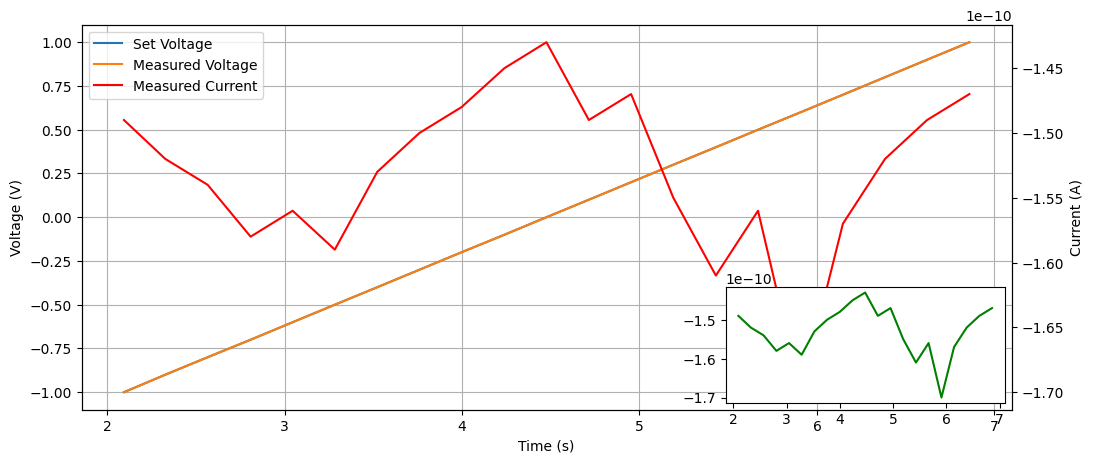

In [ ]:
time, set_volt, meas_curr, meas_volt = data.T
fig, ax = plt.subplots(1, 1, figsize=(12, 5))
twinx = ax.twinx()
l1 = ax.plot(time, set_volt, label="Set Voltage")
l2 = ax.plot(time, meas_volt, label="Measured Voltage")
l3 = twinx.plot(time, meas_curr, label="Measured Current", color="red")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Voltage (V)")
twinx.set_ylabel("Current (A)")
ax.legend(handles=l1 + l2 + l3)
ax.grid(True)

# Add inset to graph
inset_ax = inset_axes(ax, width="30%", height="30%", loc="lower right")
x_subset = (4, 6)
x_subset = (time[-1] - 5, time[-1])
inds = (time >= x_subset[0]) & (time <= x_subset[1])
# x_inset = meas_volt[inds]
x_inset = time[inds]
y_inset = meas_curr[inds]
inset_ax.plot(x_inset, y_inset, label="IV Curve", color="green")

In [9]:
device.close()

In [ ]:
df = pd.DataFrame(
    data, columns=["Time", "Set Voltage", "Measured Current", "Measured Voltage"]
)
df

,Time,Set Voltage,Measured Current,Measured Voltage
0,2.094443,-1.0,-1.490000e-10,-1.0
1,2.327333,-0.9,-1.520000e-10,-0.9
2,2.566270,-0.8,-1.540000e-10,-0.8
3,2.808452,-0.7,-1.580000e-10,-0.7
4,3.045199,-0.6,-1.560000e-10,-0.6
5,3.282921,-0.5,-1.590000e-10,-0.5
6,3.522152,-0.4,-1.530000e-10,-0.4
7,3.759930,-0.3,-1.500000e-10,-0.3
8,3.997637,-0.2,-1.480000e-10,-0.2
9,4.238905,-0.1,-1.450000e-10,-0.1


In [15]:
df.to_csv("measurement_data.csv", index=False)